# 02 - Prédiction de l'âge cérébral (BrainAgeNet)

J'entraîne un EfficientNet-B0 sur le dataset IXI (588 sujets sains, 20 à 86 ans) pour prédire l'âge cérébral depuis une coupe IRM 2D. L'âge prédit servira de feature clinique au BNN multimodal.

### 1. Imports et seed

In [1]:
import os, random, glob
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import pickle
import requests
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


/Users/teodul/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 2. Chemins et hyperparamètres

In [2]:
IXI_DIR      = os.path.expanduser("~/Documents/Memoire/IXI")
IXI_T1_DIR   = os.path.join(IXI_DIR, "T1")
IXI_CSV_PATH = os.path.join(IXI_DIR, "IXI.xls")

DATAROOT   = "/Users/teodul/Documents/Memoire/Brain Tumor MRI clean"
TRAIN_DIR  = os.path.join(DATAROOT, "Train")
TEST_DIR   = os.path.join(DATAROOT, "Test")
CLASSES    = ["glioma", "meningioma", "notumor", "pituitary"]

SAVE_DIR   = "runs_brain_age"
os.makedirs(IXI_T1_DIR, exist_ok=True)
os.makedirs(SAVE_DIR,   exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 1e-4
NUM_WORKERS = 0
PATIENCE    = 5
AGE_MIN, AGE_MAX = 20, 86

N_SLICES_PER_VOLUME = 10

### 3. Chargement du dataset IXI

In [3]:
os.makedirs(IXI_DIR, exist_ok=True)

if not os.path.exists(IXI_CSV_PATH):
    raise FileNotFoundError(f"IXI.xls introuvable → {IXI_CSV_PATH}")

df = pd.read_excel(IXI_CSV_PATH, engine="xlrd")
df = df[["IXI_ID", "AGE", "SEX_ID (1=m, 2=f)"]].copy()
df.columns = ["ixi_id", "age", "sex"]
df = df.dropna(subset=["age"])
df["ixi_id"] = df["ixi_id"].astype(int)
df["age"]    = df["age"].astype(float)

print(f"✓ {len(df)} sujets | Âge : {df['age'].min():.0f}–{df['age'].max():.0f} ans")

nii_files = sorted(glob.glob(os.path.join(IXI_T1_DIR, "IXI*.nii.gz")))
print(f"✓ {len(nii_files)} fichiers NIfTI T1 trouvés")

if len(nii_files) == 0:
    raise FileNotFoundError(f"Aucun fichier NIfTI trouvé → {IXI_T1_DIR}")

✓ 590 sujets | Âge : 20–86 ans
✓ 581 fichiers NIfTI T1 trouvés


### 4. Extraction des coupes 2D

In [4]:
SLICES_DIR = os.path.join(SAVE_DIR, "slices_2d")
os.makedirs(SLICES_DIR, exist_ok=True)

# extrait l'ID numerique depuis le nom de fichier IXI
def extract_ixi_id(filename):
    basename = os.path.basename(filename)
    try:
        return int(basename.split("-")[0].replace("IXI", ""))
    except:
        return None

# normalise une coupe 2D dans [0, 255]
def normalize_slice(s):
    s = s.astype(np.float32)
    s_min, s_max = s.min(), s.max()
    if s_max - s_min < 1e-6:
        return np.zeros_like(s, dtype=np.uint8)
    s = (s - s_min) / (s_max - s_min) * 255
    return s.astype(np.uint8)

records = []

for nii_path in tqdm(nii_files, desc="Extraction coupes"):
    ixi_id = extract_ixi_id(nii_path)
    if ixi_id is None:
        continue

    row = df[df["ixi_id"] == ixi_id]
    if row.empty:
        continue

    age = float(row["age"].values[0])
    if not (AGE_MIN <= age <= AGE_MAX):
        continue

    age_norm = (age - AGE_MIN) / (AGE_MAX - AGE_MIN)

    try:
        vol = nib.load(nii_path).get_fdata()
    except Exception as e:
        print(f"Erreur lecture {nii_path}: {e}")
        continue

    y_center = vol.shape[1] // 2
    y_start  = y_center - N_SLICES_PER_VOLUME // 2
    y_end    = y_center + N_SLICES_PER_VOLUME // 2

    for y_idx in range(y_start, y_end):
        slc = vol[:, y_idx, :]
        slc = normalize_slice(slc)
        slc_img = Image.fromarray(slc).convert("L")

        fname = f"IXI{ixi_id:04d}_y{y_idx:03d}.png"
        fpath = os.path.join(SLICES_DIR, fname)
        slc_img.save(fpath)
        records.append((fpath, age_norm))

print(f"\n✓ {len(records)} coupes extraites depuis {len(nii_files)} volumes")
print(f"  → sauvegardées dans {SLICES_DIR}")

Extraction coupes: 100%|██████████| 581/581 [00:20<00:00, 28.26it/s]


✓ 5600 coupes extraites depuis 581 volumes
  → sauvegardées dans runs_brain_age/slices_2d


### 5. Préparation des données

In [5]:
subject_ids = list(set([os.path.basename(r[0]).split("_")[0] for r in records]))
train_ids, val_ids = train_test_split(subject_ids, test_size=0.2, random_state=SEED)
train_ids, val_ids = set(train_ids), set(val_ids)

train_records = [r for r in records if os.path.basename(r[0]).split("_")[0] in train_ids]
val_records   = [r for r in records if os.path.basename(r[0]).split("_")[0] in val_ids]

print(f"Train : {len(train_records)} coupes | Val : {len(val_records)} coupes")

class IXIAgeDataset(Dataset):
    def __init__(self, records, transform):
        self.records   = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, age_norm = self.records[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), torch.tensor(age_norm, dtype=torch.float32)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

train_ds     = IXIAgeDataset(train_records, train_tf)
val_ds       = IXIAgeDataset(val_records,   val_tf)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Train : 4480 coupes | Val : 1120 coupes


### 6. Architecture et fonction de perte

In [6]:
class BrainAgeNet(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Identity()
        self.encoder = backbone

        self.age_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.age_head(self.encoder(x)).squeeze(1)

def weighted_mse_loss(pred, target):
    # pénalise plus les erreurs aux extrêmes (sujets très jeunes / très vieux)
    weights = 1.0 + 2.0 * torch.abs(target - 0.5)
    return (weights * (pred - target) ** 2).mean()

model_age = BrainAgeNet().to(device)
optimizer = torch.optim.AdamW(model_age.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

print(f"Params : {sum(p.numel() for p in model_age.parameters() if p.requires_grad):,}")

Params : 4,352,509


### 7. Entraînement

In [7]:
history = {"loss": [], "val_mae": [], "val_r2": []}
best_mae = float("inf")
patience_counter = 0

for epoch in range(EPOCHS):
    model_age.train()
    running_loss = 0.0
    for imgs, ages in train_loader:
        imgs, ages = imgs.to(device), ages.to(device)
        pred = model_age(imgs)
        loss = weighted_mse_loss(pred, ages)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running_loss += loss.item()

    scheduler.step(epoch)

    model_age.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for imgs, ages in val_loader:
            pred = model_age(imgs.to(device))
            all_true.extend(ages.numpy())
            all_pred.extend(pred.cpu().numpy())

    ages_yr  = np.array(all_true) * (AGE_MAX - AGE_MIN) + AGE_MIN
    preds_yr = np.array(all_pred) * (AGE_MAX - AGE_MIN) + AGE_MIN
    val_mae  = mean_absolute_error(ages_yr, preds_yr)
    val_r2   = r2_score(ages_yr, preds_yr)

    history["loss"].append(running_loss / len(train_loader))
    history["val_mae"].append(val_mae)
    history["val_r2"].append(val_r2)

    print(f"Epoch {epoch:2d} | Loss={running_loss/len(train_loader):.4f} | MAE={val_mae:.1f} ans | R²={val_r2:.3f}")

    if val_mae < best_mae:
        best_mae = val_mae
        patience_counter = 0
        torch.save({"model_state": model_age.state_dict(),
                    "epoch": epoch, "mae": val_mae, "r2": val_r2},
                   os.path.join(SAVE_DIR, "best.pt"))
        print(f"  ✓ Sauvegardé (MAE={val_mae:.1f} ans)")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping epoch {epoch}"); break

Epoch  0 | Loss=0.0587 | MAE=9.2 ans | R²=0.474
  ✓ Sauvegardé (MAE=9.2 ans)
Epoch  1 | Loss=0.0268 | MAE=7.2 ans | R²=0.671
  ✓ Sauvegardé (MAE=7.2 ans)
Epoch  2 | Loss=0.0205 | MAE=7.8 ans | R²=0.602
Epoch  3 | Loss=0.0160 | MAE=7.1 ans | R²=0.687
  ✓ Sauvegardé (MAE=7.1 ans)
Epoch  4 | Loss=0.0144 | MAE=7.4 ans | R²=0.661
Epoch  5 | Loss=0.0137 | MAE=7.2 ans | R²=0.684
Epoch  6 | Loss=0.0133 | MAE=7.1 ans | R²=0.685
  ✓ Sauvegardé (MAE=7.1 ans)
Epoch  7 | Loss=0.0126 | MAE=7.0 ans | R²=0.697
  ✓ Sauvegardé (MAE=7.0 ans)
Epoch  8 | Loss=0.0114 | MAE=6.5 ans | R²=0.737
  ✓ Sauvegardé (MAE=6.5 ans)
Epoch  9 | Loss=0.0100 | MAE=6.4 ans | R²=0.748
  ✓ Sauvegardé (MAE=6.4 ans)
Epoch 10 | Loss=0.0097 | MAE=6.6 ans | R²=0.730
Epoch 11 | Loss=0.0081 | MAE=6.4 ans | R²=0.745
Epoch 12 | Loss=0.0079 | MAE=6.6 ans | R²=0.734
Epoch 13 | Loss=0.0080 | MAE=6.3 ans | R²=0.754
  ✓ Sauvegardé (MAE=6.3 ans)
Epoch 14 | Loss=0.0074 | MAE=6.3 ans | R²=0.754
Epoch 15 | Loss=0.0070 | MAE=6.3 ans | R²=0.753


### 8. Évaluation

MAE = 6.1 ans
R²  = 0.772


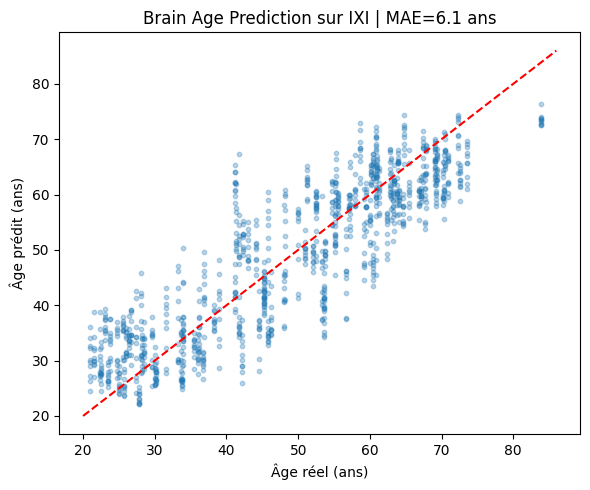

In [8]:
ckpt = torch.load(os.path.join(SAVE_DIR, "best.pt"), map_location=device, weights_only=False)
model_age.load_state_dict(ckpt["model_state"])
model_age.eval()

all_true, all_pred = [], []
with torch.no_grad():
    for imgs, ages in val_loader:
        pred = model_age(imgs.to(device))
        all_true.extend(ages.numpy())
        all_pred.extend(pred.cpu().numpy())

ages_yr  = np.array(all_true) * (AGE_MAX - AGE_MIN) + AGE_MIN
preds_yr = np.array(all_pred) * (AGE_MAX - AGE_MIN) + AGE_MIN

print(f"MAE = {mean_absolute_error(ages_yr, preds_yr):.1f} ans")
print(f"R²  = {r2_score(ages_yr, preds_yr):.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(ages_yr, preds_yr, alpha=0.3, s=10)
plt.plot([AGE_MIN, AGE_MAX], [AGE_MIN, AGE_MAX], 'r--')
plt.xlabel("Âge réel (ans)"); plt.ylabel("Âge prédit (ans)")
plt.title(f"Brain Age Prediction sur IXI | MAE={mean_absolute_error(ages_yr, preds_yr):.1f} ans")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "age_scatter_ixi.png"), dpi=150)
plt.show()

### 9. Inférence sur le dataset tumoral

In [9]:
infer_tf = val_tf

all_splits = {}
for split, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    predictions = {}
    for cls in CLASSES:
        cls_dir = os.path.join(split_dir, cls)
        paths = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")) +
                       glob.glob(os.path.join(cls_dir, "*.jpeg")) +
                       glob.glob(os.path.join(cls_dir, "*.png")))
        for path in tqdm(paths, desc=f"{split}/{cls}"):
            img_t = infer_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
            with torch.no_grad():
                age_p = model_age(img_t).item()
            age_yr   = age_p * (AGE_MAX - AGE_MIN) + AGE_MIN
            age_norm = (age_yr - AGE_MIN) / (AGE_MAX - AGE_MIN)
            predictions[path] = np.array([age_norm], dtype=np.float32)
    all_splits[split] = predictions

with open("predicted_clinical.pkl", "wb") as f:
    pickle.dump(all_splits, f)

print(f"✓ predicted_clinical.pkl sauvegardé")
print(f"  Train: {len(all_splits['train'])} | Test: {len(all_splits['test'])}")

test/pituitary: 100%|██████████| 295/295 [00:02<00:00, 139.32it/s]

✓ predicted_clinical.pkl sauvegardé
  Train: 4604 | Test: 1149


### 10. Scatter plot avec densité KDE

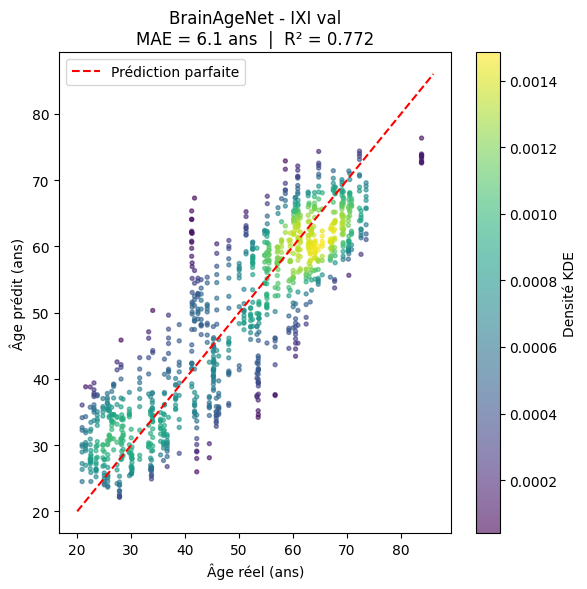

MAE = 6.13 ans  |  R² = 0.772


In [10]:
from scipy.stats import gaussian_kde

model_age.eval()
all_true, all_pred = [], []
with torch.no_grad():
    for imgs, ages in val_loader:
        pred = model_age(imgs.to(device))
        all_true.extend(ages.numpy())
        all_pred.extend(pred.cpu().numpy())

ages_yr  = np.array(all_true) * (AGE_MAX - AGE_MIN) + AGE_MIN
preds_yr = np.array(all_pred) * (AGE_MAX - AGE_MIN) + AGE_MIN

mae = mean_absolute_error(ages_yr, preds_yr)
r2  = r2_score(ages_yr, preds_yr)

xy = np.vstack([ages_yr, preds_yr])
kde = gaussian_kde(xy)
density = kde(xy)

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(ages_yr, preds_yr, c=density, cmap="viridis", s=8, alpha=0.6)
ax.plot([AGE_MIN, AGE_MAX], [AGE_MIN, AGE_MAX], "r--", lw=1.5, label="Prédiction parfaite")
plt.colorbar(sc, ax=ax, label="Densité KDE")
ax.set_xlabel("Âge réel (ans)")
ax.set_ylabel("Âge prédit (ans)")
ax.set_title(f"BrainAgeNet - IXI val\nMAE = {mae:.1f} ans  |  R² = {r2:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "age_scatter_kde.png"), dpi=150)
plt.show()
print(f"MAE = {mae:.2f} ans  |  R² = {r2:.3f}")